In [ ]:
import pandas as pd
df = pd.read_csv("/content/sample_data/Telecom_Customer_Churn_Dataset.csv")


In [ ]:
df.head()

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,52,1541.42,75408.44,Two Year,No,UPI,No
1,CUST00002,15,1317.97,73419.49,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,61,409.64,87681.15,Month-to-Month,No,Credit Card,No
3,CUST00004,21,1791.31,72417.07,Two Year,DSL,Bank Transfer,No
4,CUST00005,24,1791.34,23568.21,One Year,Fiber Optic,Debit Card,No


In [ ]:
import numpy as np
df.select_dtypes(include=np.number)

,Tenure_Months,Monthly_Charges,Total_Charges
0,52,1541.42,75408.44
1,15,1317.97,73419.49
2,61,409.64,87681.15
3,21,1791.31,72417.07
4,24,1791.34,23568.21
...,...,...,...
2495,33,479.19,25890.63
2496,52,1241.50,85917.79
2497,14,1172.06,54865.85
2498,53,778.37,57162.91


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
f=StandardScaler().fit_transform(df.select_dtypes(include=np.number))
g=pd.DataFrame(f,columns=["Tenure_Months","Monthly_Charges","Total_Charges"])


In [ ]:
d=df.select_dtypes(include=["object"])

In [ ]:
from sklearn.preprocessing import LabelEncoder
# 'd' contains all object columns from the original df: CustomerID, Contract_Type, Internet_Service, Payment_Method, Churn
# We need to encode the feature columns (Contract_Type, Internet_Service, Payment_Method)
# and exclude CustomerID (identifier) and Churn (target).
categorical_feature_columns = [col for col in d.columns if col not in ['CustomerID', 'Churn']]

encoded_categorical_features = pd.DataFrame() # Initialize an empty DataFrame

for col in categorical_feature_columns:
    le = LabelEncoder()
    # Fit and transform the column from the original 'd' DataFrame
    encoded_categorical_features[col] = le.fit_transform(d[col])

# Now 'encoded_categorical_features' contains the numerical representation
# of the selected categorical features.

In [ ]:
d.head()

,CustomerID,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,Two Year,No,UPI,No
1,CUST00002,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,Month-to-Month,No,Credit Card,No
3,CUST00004,Two Year,DSL,Bank Transfer,No
4,CUST00005,One Year,Fiber Optic,Debit Card,No


In [ ]:
d.drop("CustomerID",axis=1)

,Contract_Type,Internet_Service,Payment_Method,Churn
0,Two Year,No,UPI,No
1,Month-to-Month,DSL,Bank Transfer,No
2,Month-to-Month,No,Credit Card,No
3,Two Year,DSL,Bank Transfer,No
4,One Year,Fiber Optic,Debit Card,No
...,...,...,...,...
2495,Month-to-Month,No,Debit Card,No
2496,Two Year,No,Credit Card,No
2497,Month-to-Month,No,Credit Card,Yes
2498,One Year,Fiber Optic,UPI,No


In [ ]:
pd.concat([g, encoded_categorical_features], axis=1)

,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method
0,0.824853,0.795057,0.891582,2,2,3
1,-0.982193,0.339162,0.822047,0,0,0
2,1.264404,-1.514061,1.320641,0,2,1
3,-0.689158,1.304896,0.787002,2,0,0
4,-0.542641,1.304957,-0.920776,1,1,2
...,...,...,...,...,...,...
2495,-0.103089,-1.372162,-0.839583,0,2,2
2496,0.824853,0.183144,1.258993,2,2,1
2497,-1.031032,0.041469,0.173404,0,2,1
2498,0.873692,-0.761759,0.253710,1,1,3


In [ ]:
#FEATURE EXTRACTION

In [ ]:
y = df["Churn"]
# x is now defined in the previous cell (P6Bxrl0QYCPC) by concatenating scaled numerical and encoded categorical features.

In [ ]:
# SPILITING

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#model fitting

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
#prediction

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.726

In [ ]:
model.coef_[0]

array([-0.04556702, -0.09120738, -0.10232381, -0.01449534,  0.02740782,
       -0.08124938])

In [ ]:
x.columns

Index(['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 'Contract_Type',
       'Internet_Service', 'Payment_Method'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt


<BarContainer object of 6 artists>

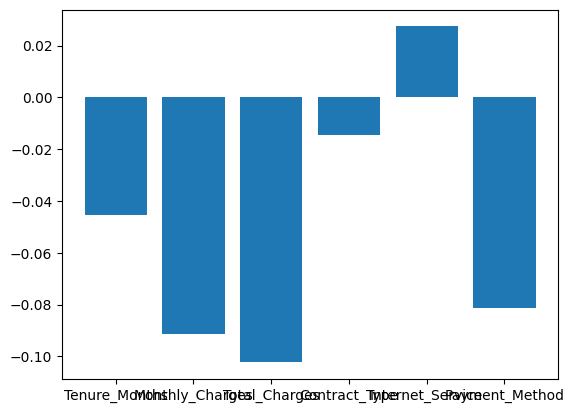

In [ ]:
plt.bar(x.columns,model.coef_[0])